# Sequential bagel analysis

## Install the package

In [1]:
if(system.file(package = "bagelR") != "")
    {
      remove.packages("bagelR")
    }
library("remotes")
install_github("grosed/bagel/bagelR",force=TRUE)

Removing package from ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)




Running `R CMD build`...



* checking for file ‘/tmp/RtmpbF1sD3/remotes4f141637eb6d8/grosed-bagel-4b1ef78/bagelR/DESCRIPTION’ ... OK
* preparing ‘bagelR’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘bagelR_1.5.0.tar.gz’


Installing package into ‘/home/grosed/DASS/R-packages’
(as ‘lib’ is unspecified)



## Check version

In [2]:
packageVersion("bagelR")

[1] ‘1.5.0’

## Load library

In [3]:
library(bagelR)


Attaching package: ‘bagelR’


The following objects are masked from ‘package:stats’:

    time, update




### Example - single change in mean

#### Define the feature vector function 

In [4]:
feature_vector <- function(t,tau)
{
  if(tau == 0)
  {
    M <- matrix(c(0),nc=1,nr=1)       
    M[1,1] <- 1
    return(M)
  }
  else
  {
    M <- matrix(c(0),nc=1,nr=2)       
    M[1,1] <- 1
    if(t > tau)
    {
      M[2,1] <- 1
    }
    return(M)
  }
}

#### Define the prior function

In [5]:
prior <- function(t)
{
  mu1 <- 1;
  delta <- c(5,1)
  if(t == 1)
  {
    mu <- matrix(c(mu1),nc=1,nr=1)
    sigma <- delta[1]*diag(1)
    return(list("mu" = mu,"sigma" = sigma))
  }
  mu <- matrix(c(mu1,0),nc=1,nr=2)
  sigma <- diag(delta)
  return(list("mu" = mu,"sigma" = sigma))
}

#### Define the transform function

In [6]:
transform <- function(tau)
{
	return(matrix(c(1,1),1,2,byrow=TRUE))
}

#### Generate some data - change at t = 501 

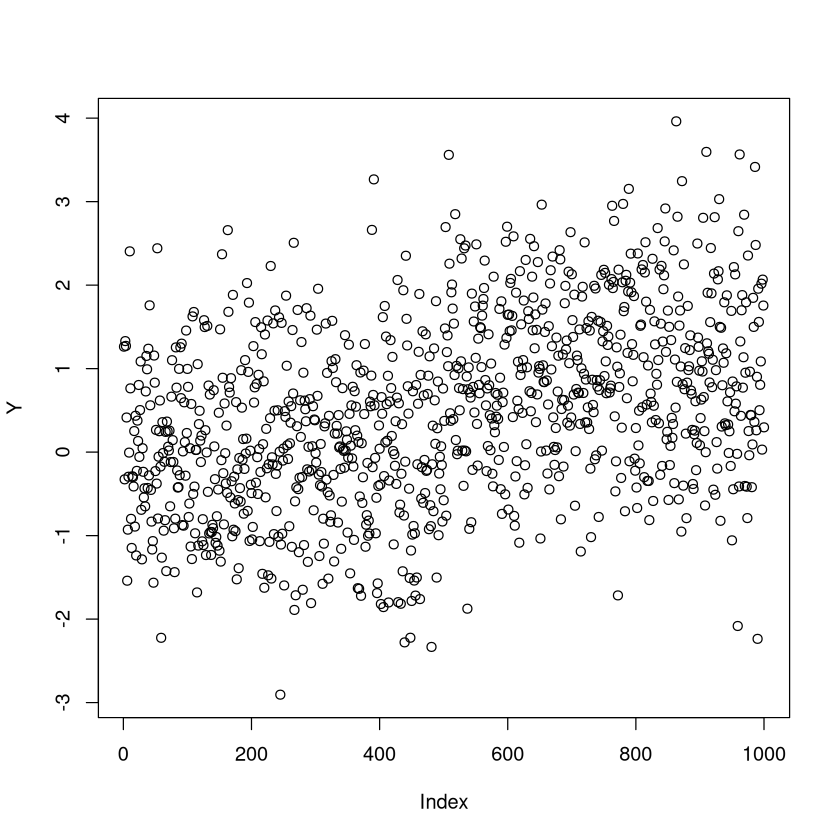

In [7]:
set.seed(0)
Y <- c(rnorm(500,0,1),rnorm(500,1,1))
plot(Y)

#### Set model parameters 

In [8]:
p <- 1.0;
p0 <- 0.9;
noise_sd <- 1.0;
max_particles <- 200
threshold <- 0.8

#### Create bagel object - known variance

In [9]:
bagel_object <- sequential_bagel_kv_approximate(feature_vector,prior,transform,p0,p,noise_sd,max_particles)

#### Analyse the first 300 data points

In [10]:
w0ts <- list()
for(y in Y[1:300])
{
   w0t <- update(bagel_object,y)
   w0ts <- append(w0ts,w0t)
   if(1.0 - w0t > threshold)
    {
	   break
    }
}

#### Examine progress

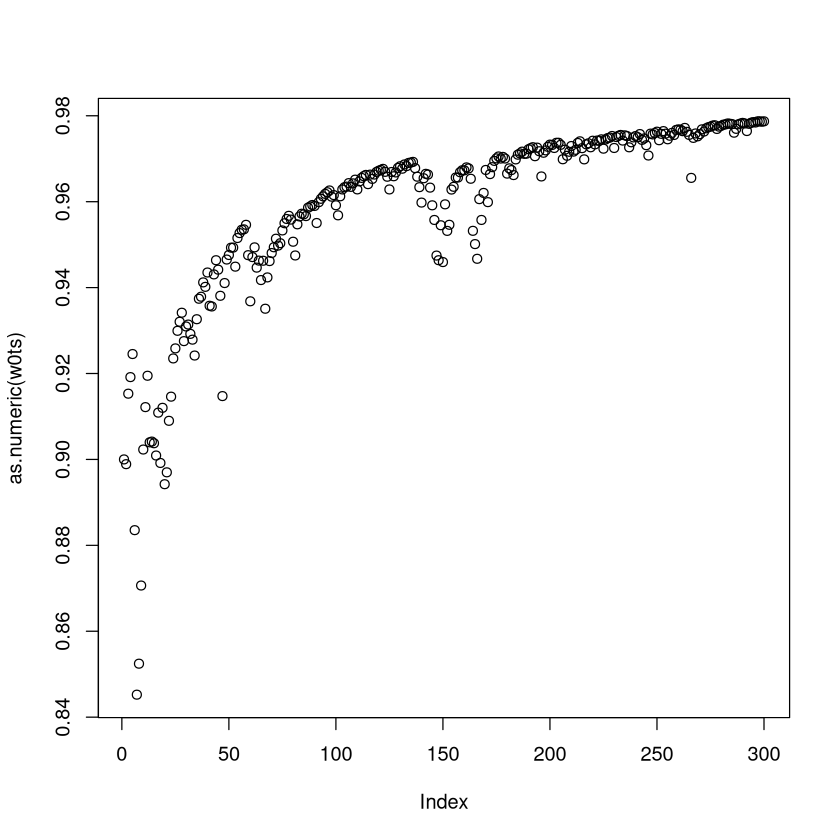

In [11]:
plot(as.numeric(w0ts))

#### Restart the analysis

In [12]:
for(y in Y[301:800])
{
   w0t <- update(bagel_object,y)
   w0ts <- append(w0ts,w0t)
   if(1.0 - w0t > threshold)
    {
	   break
    }
}

#### Examine progress

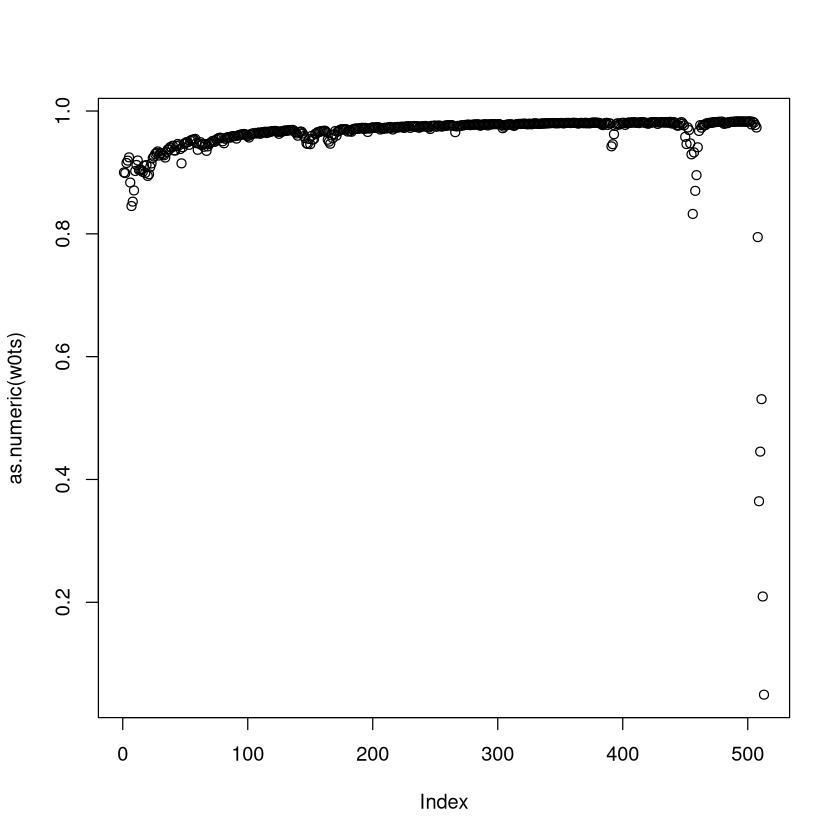

In [13]:
plot(as.numeric(w0ts))

#### Detection time

In [14]:
time(bagel_object)

[1] 513

#### Predicted changepoint location

In [15]:
which.max(weights(bagel_object))

[1] 502

#### Weight distribution around predicted changepoint

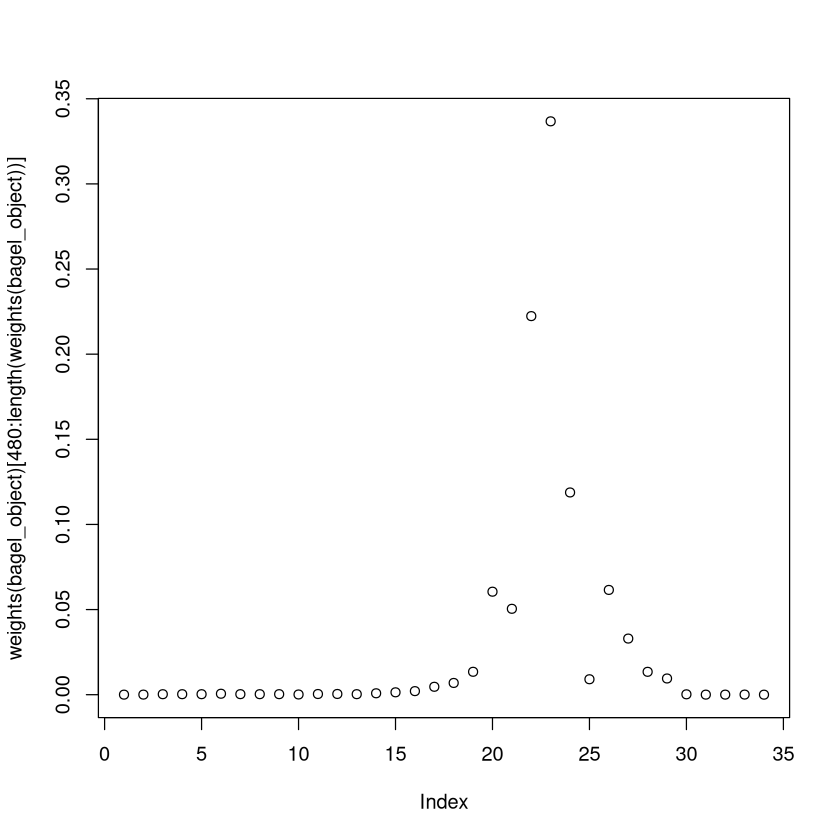

In [16]:
plot(weights(bagel_object)[480:length(weights(bagel_object))])

## Other methods available for sequential analyses

### Get the weights (reconstructed from the ratios)

In [17]:
weights(bagel_object)

[1] 4.954574e-02 1.148028e-05 7.176458e-06 1.020223e-05 1.622722e-05
  [6] 1.563019e-05 6.024508e-06 4.320555e-06 3.811502e-06 3.589702e-06
 [11] 5.411690e-06 6.408022e-06 4.590348e-06 3.505807e-06 3.194873e-06
 [16] 2.958796e-06 2.738059e-06 2.718749e-06 2.476515e-06 2.469112e-06
 [21] 2.383857e-06 2.336935e-06 2.280690e-06 2.241147e-06 2.163061e-06
 [26] 2.116736e-06 2.122483e-06 2.246125e-06 2.090182e-06 2.022316e-06
 [31] 1.997569e-06 1.960563e-06 1.976528e-06 1.965071e-06 1.982597e-06
 [36] 1.913900e-06 1.810708e-06 1.835737e-06 1.783416e-06 1.820635e-06
 [41] 1.765199e-06 1.883703e-06 1.971318e-06 1.851933e-06 1.743545e-06
 [46] 1.692608e-06 1.643876e-06 1.676869e-06 1.601965e-06 1.610894e-06
 [51] 1.587967e-06 1.593607e-06 1.558699e-06 1.605068e-06 1.520152e-06
 [56] 1.503314e-06 1.510369e-06 1.547076e-06 1.515493e-06 1.527565e-06
 [61] 1.504083e-06 1.488465e-06 1.481828e-06 1.581953e-06 1.577150e-06
 [66] 1.619197e-06 1.598375e-06 1.690976e-06 1.639343e-06 1.603836e-06
 [71] 1.592722e-06 1.586208e-06 1.553204e-06 1.604985e-06 1.608517e-06
 [76] 1.540242e-06 1.491671e-06 1.483423e-06 1.482458e-06 1.498494e-06
 [81] 1.681042e-06 1.776190e-06 1.572512e-06 1.505338e-06 1.513037e-06
 [86] 1.551769e-06 1.588202e-06 1.483421e-06 1.501376e-06 1.374850e-06
 [91] 1.344584e-06 1.349468e-06 1.317536e-06 1.316288e-06 1.328247e-06
 [96] 1.308392e-06 1.304251e-06 1.307990e-06 1.221108e-06 1.225165e-06
[101] 1.174677e-06 1.186344e-06 1.236569e-06 1.221644e-06 1.222764e-06
[106] 1.218460e-06 1.212445e-06 1.213372e-06 1.204460e-06 1.200742e-06
[111] 1.171247e-06 1.159466e-06 1.220726e-06 1.222314e-06 1.223391e-06
[116] 1.232459e-06 1.200960e-06 1.227719e-06 1.217435e-06 1.180816e-06
[121] 1.181133e-06 1.183571e-06 1.181512e-06 1.310562e-06 1.341855e-06
[126] 1.376558e-06 1.224986e-06 1.222208e-06 1.222832e-06 1.207668e-06
[131] 1.210467e-06 1.135573e-06 1.143823e-06 1.125815e-06 1.148747e-06
[136] 1.130193e-06 1.169553e-06 1.273601e-06 1.310455e-06 1.395790e-06
[141] 1.476712e-06 1.399401e-06 1.399246e-06 1.429211e-06 1.560875e-06
[146] 1.760873e-06 1.847857e-06 2.076588e-06 2.197364e-06 2.077734e-06
[151] 2.399030e-06 2.147932e-06 2.326214e-06 2.366964e-06 1.873642e-06
[156] 1.716964e-06 1.763501e-06 1.880161e-06 1.760559e-06 1.777106e-06
[161] 1.857454e-06 1.798859e-06 1.847383e-06 1.448643e-06 1.224713e-06
[166] 1.238587e-06 1.192671e-06 1.221719e-06 1.182986e-06 1.200753e-06
[171] 1.214801e-06 1.184660e-06 1.174724e-06 1.197937e-06 1.244974e-06
[176] 1.302673e-06 1.270238e-06 1.439010e-06 1.469873e-06 1.510781e-06
[181] 1.802584e-06 1.827801e-06 1.812061e-06 1.920192e-06 1.741435e-06
[186] 1.636447e-06 1.660002e-06 1.647559e-06 1.759939e-06 1.808252e-06
[191] 1.605924e-06 1.621253e-06 1.610001e-06 1.387443e-06 1.441206e-06
[196] 1.318834e-06 1.230238e-06 1.261503e-06 1.276572e-06 1.323004e-06
[201] 1.361195e-06 1.496847e-06 1.601295e-06 1.405377e-06 1.358227e-06
[206] 1.302097e-06 1.171151e-06 1.197228e-06 1.168407e-06 1.181530e-06
[211] 1.193323e-06 1.119137e-06 1.133795e-06 1.204632e-06 1.223776e-06
[216] 1.090570e-06 1.067569e-06 1.124658e-06 1.136430e-06 1.130136e-06
[221] 1.147365e-06 1.116993e-06 1.123139e-06 1.126872e-06 1.137646e-06
[226] 1.058061e-06 1.155745e-06 1.168859e-06 1.232340e-06 1.191979e-06
[231] 1.065570e-06 1.131253e-06 1.148281e-06 1.164477e-06 1.090985e-06
[236] 1.113911e-06 1.106123e-06 1.054533e-06 1.058475e-06 1.068948e-06
[241] 1.076228e-06 1.060328e-06 1.112297e-06 1.020411e-06 1.038566e-06
[246] 1.268011e-06 1.251009e-06 1.270118e-06 1.233718e-06 1.239127e-06
[251] 1.259321e-06 1.384299e-06 1.358912e-06 1.330014e-06 1.159239e-06
[256] 1.077618e-06 1.094617e-06 1.108505e-06 1.091303e-06 1.112717e-06
[261] 1.127886e-06 1.118606e-06 1.183557e-06 1.158740e-06 1.040028e-06
[266] 1.048342e-06 9.728488e-07 1.074778e-06 1.052235e-06 1.103698e-06
[271] 1.151160e-06 1.124363e-06 1.141842e-06 1.153017e-06 1.095458e-06
[276] 1.120456e-06 1.131371e-06 1.136459e-06 1.095239e-06 1.085374e-06
[281] 1.166775e-06 1.13573

#### Get the active weights

In [18]:
active_weights(bagel_object)

[1] 4.954574e-02 1.865674e-05 1.020223e-05 3.185741e-05 6.024508e-06
  [6] 1.172176e-05 1.181971e-05 4.590348e-06 2.006191e-05 9.242629e-06
 [11] 1.073859e-05 5.980448e-06 7.838095e-06 5.429861e-06 3.585833e-06
 [16] 5.706955e-06 1.743545e-06 1.296649e-05 9.201473e-06 6.001940e-06
 [21] 2.675275e-05 3.457232e-06 1.071566e-05 1.195161e-05 2.446273e-06
 [26] 2.361021e-06 9.730456e-06 2.330713e-06 1.327204e-05 4.028975e-06
 [31] 6.088161e-06 5.684152e-06 1.169553e-06 2.584056e-06 7.100361e-06
 [36] 1.560875e-06 3.608730e-06 6.351686e-06 9.240140e-06 1.627563e-05
 [41] 1.448643e-06 1.203355e-05 3.817885e-06 4.419665e-06 7.362638e-06
 [46] 6.685443e-06 3.568191e-06 4.837178e-06 2.828648e-06 5.087147e-06
 [51] 2.684199e-06 3.098141e-06 4.065700e-06 5.911639e-06 2.252932e-06
 [56] 2.428408e-06 2.158139e-06 9.043239e-06 1.058061e-06 4.748922e-06
 [61] 1.065570e-06 3.444010e-06 3.311019e-06 5.318512e-06 1.112297e-06
 [66] 2.058977e-06 7.521304e-06 4.073224e-06 8.890491e-06 2.342297e-06
 [71] 2.088371e-06 9.728488e-07 2.127013e-06 1.015782e-05 2.180613e-06
 [76] 4.660174e-06 8.693930e-06 1.027903e-06 9.868206e-06 2.047129e-06
 [81] 1.981321e-06 5.296521e-06 6.257495e-06 4.581625e-06 3.780909e-06
 [86] 2.874440e-06 1.330825e-06 3.514481e-06 2.501151e-06 1.031933e-05
 [91] 7.468339e-06 4.573245e-06 2.440581e-06 9.366748e-06 1.253563e-06
 [96] 3.431358e-06 2.222655e-06 2.394926e-06 2.805117e-06 1.313867e-06
[101] 2.964090e-06 3.227681e-06 2.974125e-06 1.347871e-06 3.236418e-06
[106] 3.501057e-06 4.442554e-06 2.505998e-06 4.398459e-06 2.011503e-06
[111] 3.162407e-06 1.517357e-06 3.557501e-06 2.748491e-06 1.517656e-06
[116] 9.580503e-06 2.408744e-06 4.394924e-06 1.813751e-06 4.698836e-06
[121] 3.861330e-06 4.826018e-06 1.525248e-06 3.811651e-06 1.798617e-06
[126] 1.604590e-06 3.002211e-06 2.807989e-06 8.105354e-06 1.563258e-06
[131] 1.383841e-06 3.003849e-06 3.467862e-06 6.346927e-06 2.625017e-06
[136] 2.071829e-06 2.309730e-06 6.837172e-06 2.441131e-06 2.031340e-06
[141] 7.104872e-06 2.047520e-06 2.804925e-06 3.487327e-06 5.071756e-06
[146] 6.533249e-06 5.727129e-06 7.303275e-06 1.137650e-05 1.583044e-05
[151] 2.905967e-05 2.366042e-05 9.515618e-05 4.212766e-05 2.938835e-05
[156] 1.665336e-05 3.235777e-05 2.504697e-05 7.533810e-05 2.421483e-05
[161] 3.266311e-05 6.087159e-05 4.079274e-05 1.084882e-04 3.032564e-05
[166] 2.326196e-05 3.694958e-05 2.557498e-05 3.671106e-05 6.121198e-05
[171] 5.951473e-04 3.021044e-04 5.676664e-04 3.239972e-04 6.226317e-04
[176] 1.303481e-04 4.081650e-04 4.313138e-04 3.136885e-04 8.339418e-04
[181] 1.401987e-03 2.101200e-03 4.649775e-03 6.904380e-03 1.345611e-02
[186] 6.049795e-02 5.045045e-02 2.223457e-01 3.367410e-01 1.187792e-01
[191] 9.077009e-03 6.153765e-02 3.296483e-02 1.344064e-02 9.527110e-03
[196] 2.250841e-04 4.133016e-05 4.883224e-05 7.404287e-05 2.012789e-05

#### Get the ratios

In [19]:
ratios(bagel_object)

[[1]]
[1] 1

[[2]]
[1] 0.6153422 0.3846578

[[3]]
[1] 1

[[4]]
[1] 0.5093703 0.4906297

[[5]]
[1] 1

[[6]]
[1] 0.3685927 0.3251646 0.3062426

[[7]]
[1] 0.457853 0.542147

[[8]]
[1] 1

[[9]]
[1] 0.1747494 0.1592507 0.1474833 0.1364805 0.1355179 0.1234436 0.1230746

[[10]]
[1] 0.2579198 0.2528431 0.2467578 0.2424794

[[11]]
[1] 0.2014288 0.1971150 0.1976501 0.2091639 0.1946422

[[12]]
[1] 0.3381546 0.3340167 0.3278287

[[13]]
[1] 0.2521694 0.2507077 0.2529437 0.2441792

[[14]]
[1] 0.3334723 0.3380818 0.3284459

[[15]]
[1] 0.5077299 0.4922701

[[16]]
[1] 0.3300715 0.3454238 0.3245046

[[17]]
[1] 1

[[18]]
[1] 0.1305371 0.1267788 0.1293233 0.1235466 0.1242352 0.1224671 0.1229020
[8] 0.1202098

[[19]]
[1] 0.1744360 0.1652075 0.1633775 0.1641443 0.1681336 0.1647012

[[20]]
[1] 0.2545118 0.2505994 0.2479973 0.2468914

[[21]]
 [1] 0.05913236 0.05895282 0.06052450 0.05974618 0.06320755 0.06127753
 [7] 0.05995031 0.05953486 0.05929140 0.05805771 0.05999327 0.06012529
[13] 0.05757320 0.05575767 0.05544937 0.05541327 0.05601271

[[22]]
[1] 0.4862393 0.5137607

[[23]]
[1] 0.1467490 0.1404803 0.1411987 0.1448133 0.1482132 0.1384349 0.1401105

[[24]]
[1] 0.1150347 0.1125024 0.1129110 0.1102393 0.1101349 0.1111354 0.1094742
[8] 0.1091277 0.1094405

[[25]]
[1] 0.4991708 0.5008292

[[26]]
[1] 0.4975294 0.5024706

[[27]]
[1] 0.1270824 0.1255485 0.1256636 0.1252213 0.1246031 0.1246984 0.1237825
[8] 0.1234004

[[28]]
[1] 0.5025273 0.4974727

[[29]]
 [1] 0.09197731 0.09209693 0.09217813 0.09286134 0.09048802 0.09250417
 [7] 0.09172932 0.08897023 0.08899412 0.08917778 0.08902266

[[30]]
[1] 0.3252842 0.3330512 0.3416646

[[31]]
[1] 0.2012079 0.2007516 0.2008540 0.1983633 0.1988232

[[32]]
[1] 0.1997788 0.2012303 0.1980620 0.2020965 0.1988324

[[33]]
[1] 1

[[34]]
[1] 0.4928689 0.5071311

[[35]]
[1] 0.1965802 0.2079771 0.1970888 0.1970669 0.2012871

[[36]]
[1] 1

[[37]]
[1] 0.4879482 0.5120518

[[38]]
[1] 0.3269349 0.3459498 0.3271153

[[39]]
[1] 0.2596313 0.2324567 0.2517510 0.2561610

[[40]]
[1] 0.1151195 0.1054930 0.1083522 0.1155200 0.1081715 0.1091882 0.1141248
[8] 0.1105247 0.1135061

[[41]]
[1] 1

[[42]]
 [1] 0.10177486 0.10292783 0.09911213 0.10152603 0.09830734 0.09978375
 [7] 0.10095115 0.09844643 0.09762072 0.09954975

[[43]]
[1] 0.3260900 0.3412027 0.3327073

[[44]]
[1] 0.3255926 0.3325757 0.3418317

[[45]]
[1] 0.2448286 0.2482536 0.2461157 0.2608021

[[46]]
[1] 0.2604817 0.2447777 0.2483009 0.2464397

[[47]]
[1] 0.49323 0.50677

[[48]]
[1] 0.3319960 0.3351651 0.3328390

[[49]]
[1] 0.4904967 0.5095033

[[50]]
[1] 0.2592483 0.2418325 0.2479785 0.2509407

[[51]]
[1] 0.492886 0.507114

[[52]]
[1] 0.4831434 0.5168566

[[53]]
[1] 0.3456665 0.3340696 0.3202639

[[54]]
[1] 0.1981093 0.2025205 0.1976452 0.1998650 0.2018599

[[55]]
[1] 0.4967468 0.5032532

[[56]]
[1] 0.4960584 0.5039416

[[57]]
[1] 0.5053289 0.4946711

[[58]]
[1] 0.1243645 0.1256663 0.1249702 0.1268754 0.1235169 0.1241965 0.1246094
[8] 0.1258007

[[59]]
[1] 1

[[60]]
[1] 0.2433699 0.2461314 0.2594989 0.2509998

[[61]]
[1] 1

[[62]]
[1] 0.3284697 0.3334138 0.3381165

[[63]]
[1] 0.3295014 0.3364254 0.3340732

[[64]]
[1] 0.1982760 0.1990171 0.2009863 0.2023550 0.1993655

[[65]]
[1] 1

[[66]]
[1] 0.4955911 0.5044089

[[67]]
[1] 0.1685893 0.1663287 0.1688694 0.1640299 0.1647490 0.1674338

[[68]]
[1] 0.3398533 0.3336206 0.3265261

[[69]]
[1] 0.1303908 0.1212101 0.1231223 0.1246844 0.1227495 0.1251581 0.1268643
[8] 0.1258205

[[70]]
[1] 0.5052975 0.4947025

[[71]]
[1] 0.4980095 0.5019905

[[72]]
[1] 1

[[73]]
[1] 0.5052991 0.4947009

[[74]]
[1] 0.1086550 0.1133274 0.1106893 0.1124101 0.1135103 0.1078437 0.1103047
[8] 0.1113793 0.1118802

[[75]]
[1] 0.5022619 0.4977381

[[76]]
[1] 0.2503715 0.2437103 0.2561251 0.2497930

[[77]]
[1] 0.1251485 0.1241047 0.1288752 0.1286928 0.1203843 0.1228095 0.1239417
[8] 0.1260433

[[78]]
[1] 1

[[79]]
[1] 0.1104816 0.1101684 0.1122876 0.1114331 0.1112263 0.1104902 0.1092471
[8] 0.1117697 0.1128961

[[80]]
[1] 0.4987009 0.5012991

[[81]]
[1] 0.502463 0.49

#### Get the weight at tau = 0

In [20]:
weights_tau_zero(bagel_object)

[1] 0.04954574

#### Get the tau values

In [21]:
taus(bagel_object)

[1]   0   2   3   5   6   9  11  12  19  23  28  31  35  38  40  43  44  52
 [19]  58  62  79  81  88  97  99 101 109 111 122 125 130 135 136 138 143 144
 [37] 146 149 153 162 163 173 176 179 183 187 189 192 194 198 200 202 205 210
 [55] 212 214 216 224 225 229 230 233 236 241 242 244 250 253 261 263 265 266
 [73] 268 277 279 283 291 292 301 303 305 310 315 319 322 324 325 328 330 339
 [91] 345 349 351 359 360 363 365 367 369 370 372 374 376 377 379 381 383 384
[109] 386 387 389 390 393 395 396 401 402 404 405 407 409 412 413 415 416 417
[127] 419 421 426 427 428 430 432 435 436 437 438 440 441 442 446 447 448 449
[145] 450 451 452 453 454 455 456 457 459 460 461 462 463 464 466 467 468 470
[163] 471 474 475 476 477 478 479 480 482 483 484 485 487 488 489 490 491 492
[181] 493 494 495 496 497 498 499 500 501 502 503 504 505 506 507 508 509 510
[199] 511 512

#### Get the time

In [22]:
time(bagel_object)

[1] 513

#### Get the maximum number of particles

In [23]:
max_particles(bagel_object)

[1] 200

#### Set the weights (used when combining analyses over multiple bagel objects)

In [24]:
weights <- active_weights(bagel_object)
weights <- 0.5*weights
set_weights(bagel_object,weights)

In [25]:
active_weights(bagel_object)

[1] 2.477287e-02 9.328368e-06 5.101114e-06 1.592871e-05 3.012254e-06
  [6] 5.860880e-06 5.909856e-06 2.295174e-06 1.003095e-05 4.621314e-06
 [11] 5.369293e-06 2.990224e-06 3.919047e-06 2.714931e-06 1.792917e-06
 [16] 2.853478e-06 8.717723e-07 6.483243e-06 4.600736e-06 3.000970e-06
 [21] 1.337638e-05 1.728616e-06 5.357828e-06 5.975803e-06 1.223136e-06
 [26] 1.180510e-06 4.865228e-06 1.165357e-06 6.636018e-06 2.014488e-06
 [31] 3.044080e-06 2.842076e-06 5.847767e-07 1.292028e-06 3.550180e-06
 [36] 7.804375e-07 1.804365e-06 3.175843e-06 4.620070e-06 8.137815e-06
 [41] 7.243213e-07 6.016776e-06 1.908942e-06 2.209832e-06 3.681319e-06
 [46] 3.342722e-06 1.784096e-06 2.418589e-06 1.414324e-06 2.543574e-06
 [51] 1.342100e-06 1.549071e-06 2.032850e-06 2.955820e-06 1.126466e-06
 [56] 1.214204e-06 1.079070e-06 4.521619e-06 5.290307e-07 2.374461e-06
 [61] 5.327849e-07 1.722005e-06 1.655509e-06 2.659256e-06 5.561484e-07
 [66] 1.029489e-06 3.760652e-06 2.036612e-06 4.445246e-06 1.171149e-06
 [71] 1.044185e-06 4.864244e-07 1.063507e-06 5.078912e-06 1.090307e-06
 [76] 2.330087e-06 4.346965e-06 5.139517e-07 4.934103e-06 1.023565e-06
 [81] 9.906604e-07 2.648261e-06 3.128747e-06 2.290812e-06 1.890454e-06
 [86] 1.437220e-06 6.654125e-07 1.757241e-06 1.250575e-06 5.159665e-06
 [91] 3.734170e-06 2.286622e-06 1.220291e-06 4.683374e-06 6.267814e-07
 [96] 1.715679e-06 1.111327e-06 1.197463e-06 1.402559e-06 6.569336e-07
[101] 1.482045e-06 1.613840e-06 1.487062e-06 6.739353e-07 1.618209e-06
[106] 1.750529e-06 2.221277e-06 1.252999e-06 2.199229e-06 1.005752e-06
[111] 1.581203e-06 7.586785e-07 1.778751e-06 1.374245e-06 7.588279e-07
[116] 4.790252e-06 1.204372e-06 2.197462e-06 9.068756e-07 2.349418e-06
[121] 1.930665e-06 2.413009e-06 7.626241e-07 1.905825e-06 8.993083e-07
[126] 8.022952e-07 1.501105e-06 1.403994e-06 4.052677e-06 7.816290e-07
[131] 6.919204e-07 1.501925e-06 1.733931e-06 3.173464e-06 1.312509e-06
[136] 1.035915e-06 1.154865e-06 3.418586e-06 1.220565e-06 1.015670e-06
[141] 3.552436e-06 1.023760e-06 1.402462e-06 1.743663e-06 2.535878e-06
[146] 3.266625e-06 2.863565e-06 3.651638e-06 5.688248e-06 7.915220e-06
[151] 1.452983e-05 1.183021e-05 4.757809e-05 2.106383e-05 1.469418e-05
[156] 8.326679e-06 1.617888e-05 1.252348e-05 3.766905e-05 1.210742e-05
[161] 1.633156e-05 3.043579e-05 2.039637e-05 5.424410e-05 1.516282e-05
[166] 1.163098e-05 1.847479e-05 1.278749e-05 1.835553e-05 3.060599e-05
[171] 2.975737e-04 1.510522e-04 2.838332e-04 1.619986e-04 3.113158e-04
[176] 6.517407e-05 2.040825e-04 2.156569e-04 1.568442e-04 4.169709e-04
[181] 7.009937e-04 1.050600e-03 2.324888e-03 3.452190e-03 6.728054e-03
[186] 3.024897e-02 2.522523e-02 1.111728e-01 1.683705e-01 5.938962e-02
[191] 4.538505e-03 3.076882e-02 1.648242e-02 6.720320e-03 4.763555e-03
[196] 1.125420e-04 2.066508e-05 2.441612e-05 3.702143e-05 1.006395e-05